In [1]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text

warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"

GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_latent_20_2025-08-04.h5ad"
GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_standard_20_1024_2025-08-03.h5ad"

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load splicing data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(f"Done reading the ge_adata with scVI...")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
aging_genes_mouse = [g.upper() for g in aging_genes_mouse]

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
print(f"Renaming mouse.id to donor_id in splice_adata.obs")
# Update gene annotations
ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
rbps = rbps["mouse_gene_name"]

Done reading the ge_adata with scVI...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Renaming mouse.id to donor_id in splice_adata.obs


In [3]:
# Main parameters to change
MODEL_TRAIN_DATE = "2025-07-30"
MODEL_ANALYSIS_DATE = "2025-07-31"
PARAM_ID = 0

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"

# Main data files from downstream analysis of model 
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
PERPLEXITY_PATH =  f"{DATA_DIR}/cell_metadata_with_perplexity_param_id_{PARAM_ID}.csv.gz"
DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)

pi = np.load(PI_VALUES_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)
perplexity_df = pd.read_csv(PERPLEXITY_PATH)
perplexity_df = perplexity_df.set_index("cell_id")
leaflet_model = load_model(MODEL_PATH)

splice_adata.obs_names = splice_adata.obs["cell_id"]
assert all(splice_adata.obs_names == perplexity_df.index), "Cell IDs in filtered_splice_adata and perplexity_df do not match or are not in the same order"
splice_adata.obs["perplexity"] = perplexity_df["perplexity"]

print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")
print(f"Loaded diff_spl: {diff_spl.shape}")

MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"
leaflet_model = load_model(MODEL_PATH)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Loading data for param_id 0 from 2025-07-30
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/data
Loading model to device: cpu
Loaded splice_adata: (137936, 35197)
Loaded PI values: (20,)
Loaded diff_spl: (79097, 44)
Loading model to device: cpu
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs


### Add module labels to cell types 

In [4]:
# Always assert after creation or reuse
assert all(splice_adata.obs_names == ge_adata.obs_names)
splice_adata.obs["AgingScore_unweighted"] = ge_adata.obs["AgingScore_unweighted"]
splice_adata.obs["total_counts"] = ge_adata.obs["total_counts"]
splice_adata.obs["nuclear_class_log_norm"] = ge_adata.obs["nuclear_class_log_norm"]
splice_adata.obs["nuclear_score_log_norm"] = ge_adata.obs["nuclear_score_log_norm"]

## Rename factors to be in order that matches PI

In [5]:
# Number of factors (K)
K = splice_adata.obsm["X_PHI"].shape[1]

# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")

old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
print(old_to_new_factor_idx)

# Reorder X_PHI (cell × K)
splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]

# Reorder psi_learned (junction × K)
splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]

# Generate column names: SP_1, SP_2, ..., SP_K
phi_colnames = [f"SP_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"], 
    index=splice_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)

# Step 2: Rename and map
diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)

Sorted pi values with original factor indices:
Rank 1: Factor 2 → PI = 0.1451
Rank 2: Factor 0 → PI = 0.1417
Rank 3: Factor 1 → PI = 0.1131
Rank 4: Factor 6 → PI = 0.0708
Rank 5: Factor 12 → PI = 0.0475
Rank 6: Factor 4 → PI = 0.0439
Rank 7: Factor 13 → PI = 0.0421
Rank 8: Factor 9 → PI = 0.0389
Rank 9: Factor 14 → PI = 0.0385
Rank 10: Factor 3 → PI = 0.0378
Rank 11: Factor 11 → PI = 0.0373
Rank 12: Factor 15 → PI = 0.0368
Rank 13: Factor 7 → PI = 0.0362
Rank 14: Factor 5 → PI = 0.0351
Rank 15: Factor 8 → PI = 0.0350
Rank 16: Factor 10 → PI = 0.0313
Rank 17: Factor 16 → PI = 0.0212
Rank 18: Factor 17 → PI = 0.0178
Rank 19: Factor 18 → PI = 0.0164
Rank 20: Factor 19 → PI = 0.0135
{2: 0, 0: 1, 1: 2, 6: 3, 12: 4, 4: 5, 13: 6, 9: 7, 14: 8, 3: 9, 11: 10, 15: 11, 7: 12, 5: 13, 8: 14, 10: 15, 16: 16, 17: 17, 18: 18, 19: 19}


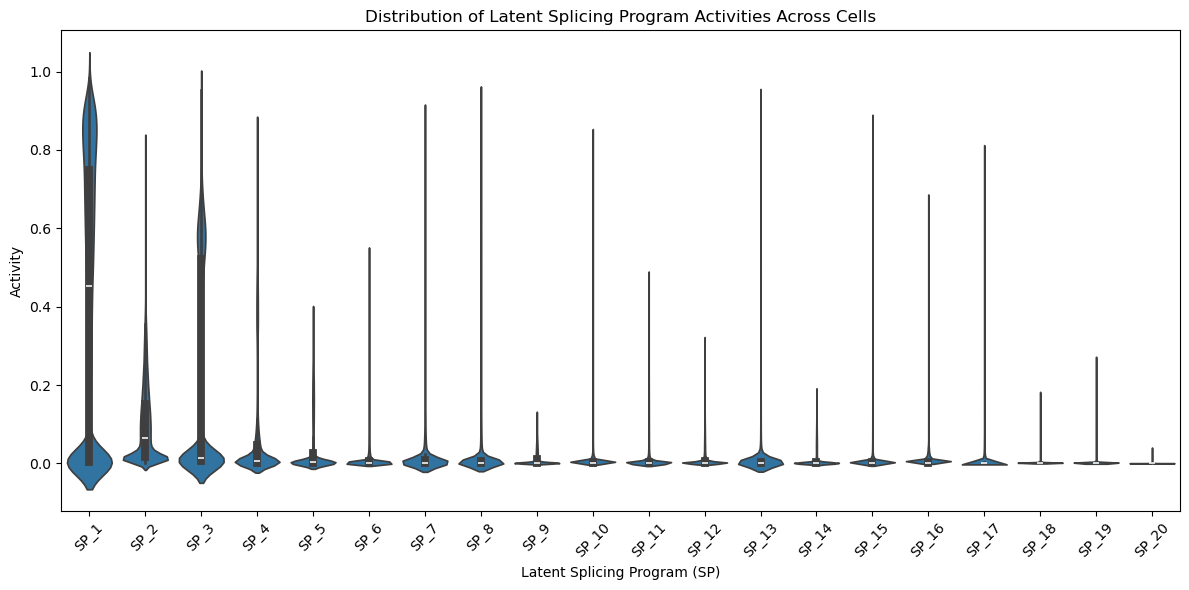

In [6]:
# Extract X_PHI matrix and convert to DataFrame
phi = pd.DataFrame(
    splice_adata.obsm["X_PHI"],
    index=splice_adata.obs["cell_id"]
)
phi.columns = [f"SP_{i+1}" for i in range(phi.shape[1])]

phi_long = phi.reset_index().melt(id_vars="cell_id", var_name="Splicing Program", value_name="Activity")

# Plot
plt.figure(figsize=(12, 6))  # Adjust width as needed
sns.violinplot(data=phi_long, x="Splicing Program", y="Activity", inner="box", scale="width")
plt.xticks(rotation=45)
plt.title("Distribution of Latent Splicing Program Activities Across Cells")
plt.xlabel("Latent Splicing Program (SP)")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

In [7]:
# Clean up Broad Cell Type column
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()
splice_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]

In [8]:
# Setup
phi_matrix = splice_adata.obsm["X_PHI"]
factor_names = [f"SP_{i+1}" for i in range(phi_matrix.shape[1])]

# Build DataFrame
phi_df = pd.DataFrame(phi_matrix, index=splice_adata.obs_names, columns=factor_names)
phi_df["broad_cell_type"] = splice_adata.obs["broad_cell_type"].values
phi_df["age_group"] = splice_adata.obs["age_group"].values

# Output dirs
output_dir_celltype = "./factor_violin_plots_by_celltype"
output_dir_agegroup = "./factor_violin_plots_by_agegroup"
output_dir_factors_by_celltype = "./factor_violin_per_celltype"

os.makedirs(output_dir_factors_by_celltype, exist_ok=True)
os.makedirs(output_dir_celltype, exist_ok=True)
os.makedirs(output_dir_agegroup, exist_ok=True)

In [9]:
# Toggle this to enable or disable plotting
MAKE_PLOTS = False

if MAKE_PLOTS:
    # --- Plot factor activity across broad cell types ---
    for factor in factor_names:
        # Order broad_cell_type by decreasing median activity
        medians = phi_df.groupby("broad_cell_type")[factor].median().sort_values(ascending=False)
        ordered_types = medians.index.tolist()

        plt.figure(figsize=(10, 5))
        sns.violinplot(
            data=phi_df, x="broad_cell_type", y=factor,
            order=ordered_types, inner="box", scale="width",
            fill="simple_category"
        )
        plt.xticks(rotation=45, ha='right')
        plt.title(f"{factor} Activity Across Broad Cell Types")
        plt.xlabel("Broad Cell Type")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_celltype, f"{factor}_by_celltype_violin.pdf"))
        plt.close()

    # --- Plot factor activity across age groups ---
    for factor in factor_names:
        # Define age group order (assumes string labels like "3m", "18m", etc.)
        age_order = phi_df["age_group"].unique().tolist()
        age_order.sort()

        plt.figure(figsize=(6, 5))
        sns.violinplot(
            data=phi_df, x="age_group", y=factor,
            order=age_order, inner="box", scale="width"
        )
        plt.title(f"{factor} Activity Across Age Groups")
        plt.xlabel("Age Group")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_agegroup, f"{factor}_by_agegroup_violin.pdf"))
        plt.close()

    # --- Melt wide-format dataframe into long-form for factor plotting ---
    phi_long = phi_df.reset_index().melt(
        id_vars=["cell_id", "broad_cell_type", "age_group"],
        value_vars=factor_names,
        var_name="Factor", value_name="Activity"
    )

    # --- Plot violin plots of all factors within each cell type ---
    for celltype in phi_df["broad_cell_type"].unique():
        # Subset data to current cell type
        subset = phi_long[phi_long["broad_cell_type"] == celltype]

        # Order factors by median activity within the current cell type
        median_order = (
            subset.groupby("Factor")["Activity"]
            .median()
            .sort_values(ascending=False)
            .index.tolist()
        )

        plt.figure(figsize=(14, 5))
        sns.violinplot(
            data=subset, x="Factor", y="Activity",
            order=median_order, inner="box", scale="width"
        )
        plt.xticks(rotation=90, ha='right')
        plt.title(f"Factor Activity in {celltype} (Ordered by Median)")
        plt.xlabel("Factor")
        plt.ylabel("Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_factors_by_celltype, f"{celltype}_factor_activity_violin.pdf"))
        plt.close()

## Visualize Pi vs PVE

In [10]:
# get reordered pi values 
new_pi = pi[new_order]

# visualize global learned pi values, vs how much variance each one explains across cells PHI? 
# How much variance each factor contributes in the loadings
phi_var = np.var(splice_adata.obsm["X_PHI"], axis=0)  # Variance across cells for each factor
pve_factor_space = phi_var / np.sum(phi_var)
print(pve_factor_space)

[4.62372695e-01 3.33069429e-02 2.63909397e-01 5.93519039e-02
 2.02442258e-02 4.54443915e-03 4.90022523e-02 4.25365570e-02
 1.29878640e-03 2.31055705e-03 5.02184057e-03 2.06518202e-03
 4.66411920e-02 2.33355028e-03 4.10285275e-03 1.75092130e-04
 6.82580185e-04 7.39708063e-06 9.05349932e-05 2.02096051e-06]


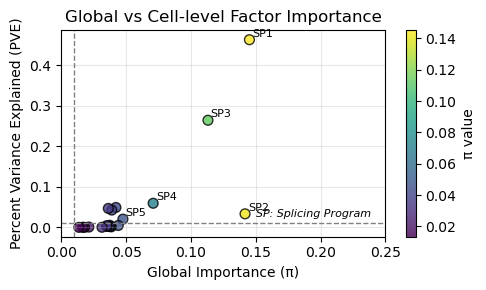

In [11]:
# Simple scatter plot
plt.figure(figsize=(5, 3))

# Use scatter with edgecolors for black outline and c parameter for color mapping
plt.scatter(new_pi, pve_factor_space, s=50, alpha=0.8, 
            c=new_pi, cmap='viridis', edgecolors='black', linewidth=1)

# Add colorbar to show π value mapping
plt.colorbar(label='π value')

# Add factor labels for interesting points
for i in range(len(new_pi)):
    if i < 5 or pve_factor_space[i] > 0.05:  # Label first 3 and high variance factors
        plt.annotate(f'SP{i+1}', (new_pi[i], pve_factor_space[i]), 
                    xytext=(2, 2), textcoords='offset points', fontsize=8)  # Increased from (5,5) to (10,10)

plt.xlabel('Global Importance (π)')
plt.ylabel('Percent Variance Explained (PVE)')
plt.title('Global vs Cell-level Factor Importance')
plt.xlim(0, 0.25)

# add dashed hori line at 0.01
plt.axhline(0.01, color='gray', linestyle='--', linewidth=1)
plt.axvline(0.01, color='gray', linestyle='--', linewidth=1)

# Add SP definition at bottom of plot
plt.text(0.15, 0.02, 'SP: Splicing Program', fontsize=8, style='italic', 
         transform=plt.gca().transData, verticalalignment='bottom')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/factor_pi_vs_pve.pdf


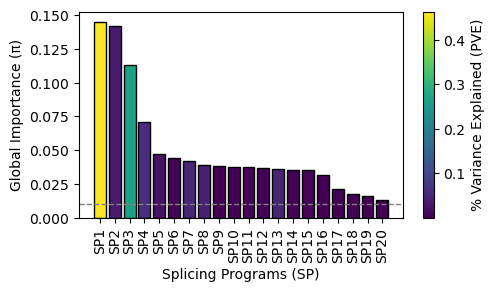

In [12]:
# Assume new_pi and pve_factor_space already exist
num_factors = len(new_pi)
factor_labels = [f'SP{i+1}' for i in range(num_factors)]

# Normalize PVE for colormap
norm = plt.Normalize(pve_factor_space.min(), pve_factor_space.max())
colors = plt.cm.viridis(norm(pve_factor_space))

# Set up figure and axis
fig, ax = plt.subplots(figsize=(5, 3))

# Bar plot
bars = ax.bar(
    factor_labels,
    new_pi,
    color=colors,
    edgecolor='black'
)

# Create scalar mappable and colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # Required dummy
cbar = plt.colorbar(sm, ax=ax)  # Pass ax explicitly
cbar.set_label("% Variance Explained (PVE)")

# Add horizontal threshold line
ax.axhline(0.01, color='gray', linestyle='--', linewidth=1)

# Formatting
ax.set_ylabel('Global Importance (π)')
ax.set_xlabel('Splicing Programs (SP)')
# ax.set_title('Factor Importance (π), colored by PVE')
ax.set_xticks(np.arange(num_factors))
ax.set_xticklabels(factor_labels, rotation=90, fontsize=10)

plt.tight_layout()

# Save to output_dir with today's date OUTPUT_DIR 
output_path = os.path.join(OUTPUT_DIR, f"factor_pi_vs_pve.pdf")
plt.savefig(output_path, format='pdf', bbox_inches='tight')
print(f"Plot saved to: {output_path}")

plt.show()


## Visualize Perplexity

In [13]:
# Step 2: Reindex to match AnnData.obs_names (i.e., cell IDs)
perplexity_df = perplexity_df.reindex(splice_adata.obs_names)

# Step 3: Add as a new column in AnnData.obs
splice_adata.obs["perplexity"] = perplexity_df["perplexity"].values

# Step 4: Filter medium_cell_types with >= 50 cells
valid_medium_ct = (
    splice_adata.obs["medium_cell_type"]
    .value_counts()[lambda x: x >= 50]
    .index
)

# Subset AnnData object to only those cells
splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Ensure ge_adata is subsetted to match
ge_adata = ge_adata[ge_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Assert order of cells is the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [14]:
splice_adata, ge_adata

(AnnData object with n_obs × n_vars = 137893 × 35197
     obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'perplexity', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20'
     var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'n_cells_detect

Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/perplexity_by_age_rasterized.pdf


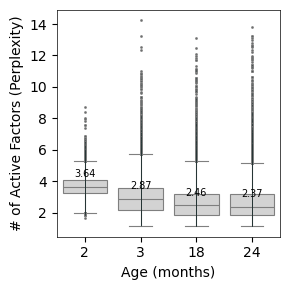

In [15]:
plt.figure(figsize=(3, 3))

# Boxplot: keep as vector
sns.boxplot(
    data=splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot: will rasterize below
stripplot = sns.stripplot(
    data=splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    splice_adata.obs
    .groupby("age_numeric", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Age (months)", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{OUTPUT_DIR}/perplexity_by_age_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/perplexity_by_sex_rasterized.pdf


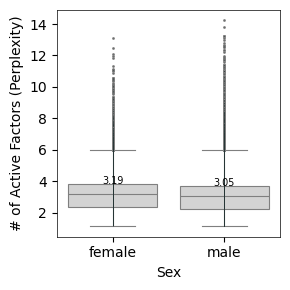

In [16]:
plt.figure(figsize=(3, 3))

# Boxplot: keep as vector
sns.boxplot(
    data=splice_adata.obs,
    x="sex", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot: will rasterize below
stripplot = sns.stripplot(
    data=splice_adata.obs,
    x="sex", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    splice_adata.obs
    .groupby("sex", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Sex", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{OUTPUT_DIR}/perplexity_by_sex_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

In [17]:
splice_adata.obs["medium_cell_type"].value_counts()

medium_cell_type
Cortical excitatory neuron      28335
Inhibitory neuron               15936
Microglia                       12079
B cell                           8640
Skin epithelial cell             7343
Endothelial cell                 7103
Mesenchymal stem cell            4780
Fibroblast                       4623
Hippocampal neuron               3993
T cell                           3588
T cell precursor                 3012
Intestinal epithelial cell       2940
Granulocyte                      2864
Hematopoietic stem cell          2749
Other immune cell                2575
Skeletal muscle cell             2469
Macrophage                       2154
Smooth muscle cell               2056
Pancreatic endocrine cell        1454
Oligodendrocyte                  1334
Monocyte                         1295
Specialized intestinal cell      1290
Immune progenitor                1210
Basal epithelial cell            1149
Urogenital epithelial cell       1014
Epithelial stem cell             

Saved rasterized plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/perplexity_by_cell_type_ordered_rasterized.pdf


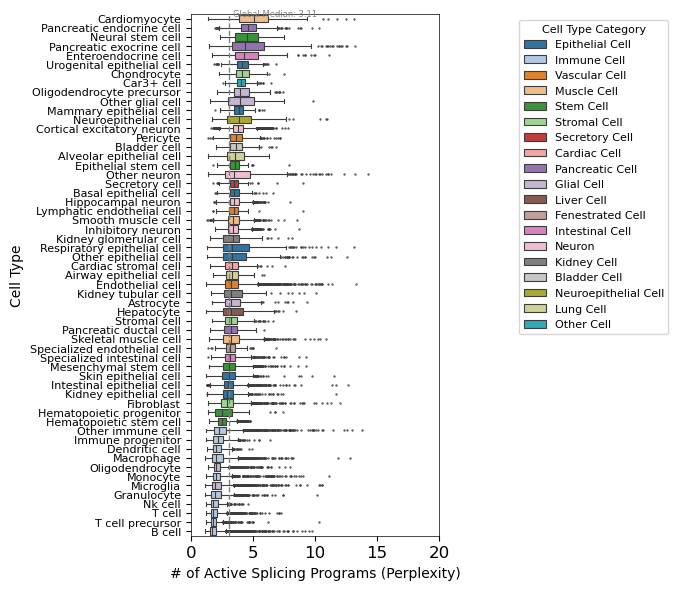

In [18]:
# Step 1: Compute median perplexity by medium_cell_type
median_order = (
    splice_adata.obs
    .groupby("medium_cell_type", observed=True)["perplexity"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Step 2: Color palette for broad_cell_type
unique_broad = splice_adata.obs["broad_cell_type"].unique()
palette = sns.color_palette("tab20", len(unique_broad))
palette_dict = dict(zip(unique_broad, palette))

# Step 3: Start figure
fig, ax = plt.subplots(figsize=(8, 6))

# Step 4: Main plot
bp = sns.boxplot(
    data=splice_adata.obs,
    y="medium_cell_type", 
    x="perplexity", 
    hue="broad_cell_type", 
    fliersize=0.6, 
    linewidth=0.8,
    order=median_order,
    palette=palette_dict,
    ax=ax
)

# Rasterize fliers
for c in ax.collections:
    if isinstance(c, plt.collections.PathCollection):
        c.set_rasterized(True)

# Global median line
global_median = splice_adata.obs["perplexity"].median()
ax.axvline(global_median, color='gray', linestyle='--', linewidth=1)
ax.text(global_median + 0.3, -1, f"Global Median: {global_median:.2f}",
        color='gray', fontsize=6, va='top')

# Legend
ax.legend(
    title="Cell Type Category",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=8,
    frameon=True
)

# Axis formatting
ax.set_ylabel("Cell Type", fontsize=10)
ax.set_xlabel("# of Active Splicing Programs (Perplexity)", fontsize=10)
ax.set_xticks(np.arange(0, 25, 5))
ax.set_xticklabels(np.arange(0, 25, 5), fontsize=12)
ax.tick_params(axis='y', labelsize=8)  # ⬅️ Smaller font for cell type labels

# Border
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Save
plt.tight_layout()
pdf_path = f"{OUTPUT_DIR}/perplexity_by_cell_type_ordered_rasterized.pdf"
plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
print(f"Saved rasterized plot to: {pdf_path}")
plt.show()

In [19]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")

import utils  # or: from utils import your_function
import importlib
importlib.reload(utils)

<module 'utils' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/utils.py'>

## Get correlation matrix plot

In [20]:
# Remake PHI matrix correlation plot
X_PHI_corr_matrix = plot_correlation_matrix(splice_adata.obsm["X_PHI"], OUTPUT_DIR)

Saved correlation matrix to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/correlation_matrix_PHI.pdf


### Figure 2 Factor Covaraites Labels

Running variance explained analysis...


Analyzing factors for variance explained:   0%|          | 0/20 [00:00<?, ?it/s]

  Formula: SP_1 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained:   5%|▌         | 1/20 [00:04<01:27,  4.60s/it]

                       sum_sq        df            F         PR(>F)    SP
C(cell_type)      1014.563043      56.0  1753.865998   0.000000e+00  SP_1
C(tissue)           71.745117      22.0   315.700350   0.000000e+00  SP_1
C(sex)               0.040594       1.0     3.929735   4.744139e-02  SP_1
C(dataset)           0.907524       1.0    87.854447   7.146881e-21  SP_1
age                 38.078483       1.0  3686.252164   0.000000e+00  SP_1
C(cell_type):age    24.854780      56.0    42.966234   0.000000e+00  SP_1
C(tissue):age       12.965532      22.0    57.052288  1.165967e-250  SP_1
C(sex):age           3.326964       1.0   322.072430   6.189132e-72  SP_1
Residual          1422.845795  137741.0          NaN            NaN  SP_1
  Formula: SP_2 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


...

Analyzing factors for variance explained:  95%|█████████▌| 19/20 [01:26<00:04,  4.61s/it]

                    sum_sq        df           F        PR(>F)     SP
C(cell_type)      0.009024      56.0    7.201824  1.914603e-48  SP_19
C(tissue)         0.000793      22.0    1.610664  3.785939e-02  SP_19
C(sex)            0.000180       1.0    8.057847  4.531361e-03  SP_19
C(dataset)        0.000066       1.0    2.929917  8.695419e-02  SP_19
age               0.000174       1.0    7.791171  5.250937e-03  SP_19
C(cell_type):age  0.199483      56.0  159.205158  0.000000e+00  SP_19
C(tissue):age     0.000147      22.0    0.298129  9.993933e-01  SP_19
C(sex):age        0.000289       1.0   12.915036  3.260668e-04  SP_19
Residual          3.081939  137741.0         NaN           NaN  SP_19
  Formula: SP_20 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained: 100%|██████████| 20/20 [01:31<00:00,  4.57s/it]

                        sum_sq        df           F         PR(>F)     SP
C(cell_type)      6.687053e-03      56.0  253.955601   0.000000e+00  SP_20
C(tissue)         5.652475e-04      22.0   54.642056  9.686229e-229  SP_20
C(sex)            4.734320e-11       1.0    0.000101   9.919940e-01  SP_20
C(dataset)        2.941135e-05       1.0   62.549805   2.617008e-15  SP_20
age               1.737611e-04       1.0  369.541889   3.019755e-82  SP_20
C(cell_type):age  1.235781e-03      56.0   46.931510   0.000000e+00  SP_20
C(tissue):age     1.048749e-04      22.0   10.138175   3.582209e-35  SP_20
C(sex):age        5.179990e-05       1.0  110.164058   9.225212e-26  SP_20
Residual          6.476676e-02  137741.0         NaN            NaN  SP_20


  Saved variance explained heatmap to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/variance_explained_heatmap_medium_cell_type.pdf


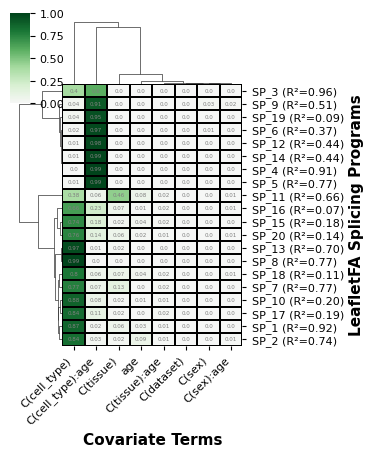

In [21]:
# read in factor labels 
factor_labels_medium_cell_type = utils.run_variance_explained_analysis(splice_adata, cell_type_col="medium_cell_type", sample_id="dataset", PLOTS_DIR=OUTPUT_DIR)

In [22]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")
import figure_plotting
import importlib
importlib.reload(figure_plotting)

<module 'figure_plotting' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/figure_plotting.py'>

### Plot correlation plot between PHI SP1 and SP2 

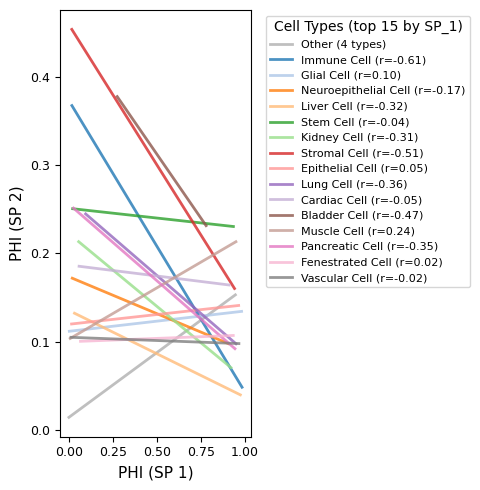

In [23]:
from scipy.stats import spearmanr, linregress

cell_type_col = "broad_cell_type"
cell_types_show = 15  # Easy to modify number of cell types to show

# Get factor activities
PHI_CELLS = splice_adata.obsm["X_PHI"]
ix_x = 0
ix_y = 1
x, y = PHI_CELLS[:, ix_x], PHI_CELLS[:, ix_y]

# Create DataFrame for easier manipulation
df = pd.DataFrame({
    'SP_1': x,
    'SP_2': y,
    'cell_type': splice_adata.obs[cell_type_col].values
})

# Find top N cell types by median SP_1 expression
cell_type_medians = df.groupby('cell_type')['SP_1'].median().sort_values(ascending=False)
top_cell_types = cell_type_medians.head(cell_types_show).index.tolist()

# Set up color palette - use tab20 for more colors
if cell_types_show <= 10:
    colors = sns.color_palette("tab10", n_colors=cell_types_show)
else:
    colors = sns.color_palette("tab20", n_colors=min(cell_types_show, 20))
    
color_dict = {ct: colors[i] for i, ct in enumerate(top_cell_types)}

# Set publication-ready style
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8
})

# Create figure
fig, ax = plt.subplots(figsize=(5, 5))

# Plot regression lines for "Other" cell types (combined)
other_mask = ~df['cell_type'].isin(top_cell_types)
if other_mask.sum() > 0:
    x_other = df.loc[other_mask, 'SP_1'].values
    y_other = df.loc[other_mask, 'SP_2'].values
    
    # Fit regression line
    slope, intercept, r_value, p_value, std_err = linregress(x_other, y_other)
    x_line = np.array([x_other.min(), x_other.max()])
    y_line = slope * x_line + intercept
    
    ax.plot(x_line, y_line, color='grey', alpha=0.5, linewidth=2,
            label=f'Other ({len(cell_type_medians)-cell_types_show} types)', 
            zorder=1)

# Plot regression lines for top N cell types
for i, cell_type in enumerate(top_cell_types):
    mask = df['cell_type'] == cell_type
    if mask.sum() < 10:  # Skip if too few cells
        continue
    
    x_ct = df.loc[mask, 'SP_1'].values
    y_ct = df.loc[mask, 'SP_2'].values
    
    # Fit regression line
    slope, intercept, r_value, p_value, std_err = linregress(x_ct, y_ct)
    
    # Create line points
    x_line = np.array([x_ct.min(), x_ct.max()])
    y_line = slope * x_line + intercept
    
    # Plot line with cell type specific color
    ax.plot(x_line, y_line, color=color_dict[cell_type],
            alpha=0.8, linewidth=2,
            label=f'{cell_type[:20]}... (r={r_value:.2f})' if len(cell_type) > 20
                  else f'{cell_type} (r={r_value:.2f})',
            zorder=2)

# Labels and title
ax.set_xlabel(f"PHI (SP {ix_x+1})")
ax.set_ylabel(f"PHI (SP {ix_y+1})")

# Add legend (outside plot area for clarity)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
          title=f'Cell Types (top {cell_types_show} by SP_1)')

plt.tight_layout()
# save to output dir
plt.savefig(f"{OUTPUT_DIR}/PHI_SP1_SP2_correlation_plot.pdf", bbox_inches='tight')
plt.show()


Top 2 positively correlated factor pairs:
factor_i factor_j      rho
     SP8     SP13 0.566261
     SP1      SP7 0.563102

Top 2 negatively correlated factor pairs:
factor_i factor_j       rho
    SP14     SP15 -0.311977
    SP14     SP17 -0.291739

Top 2 least correlated factor pairs:
factor_i factor_j       rho
     SP9     SP12 -0.003205
    SP16     SP18  0.004100


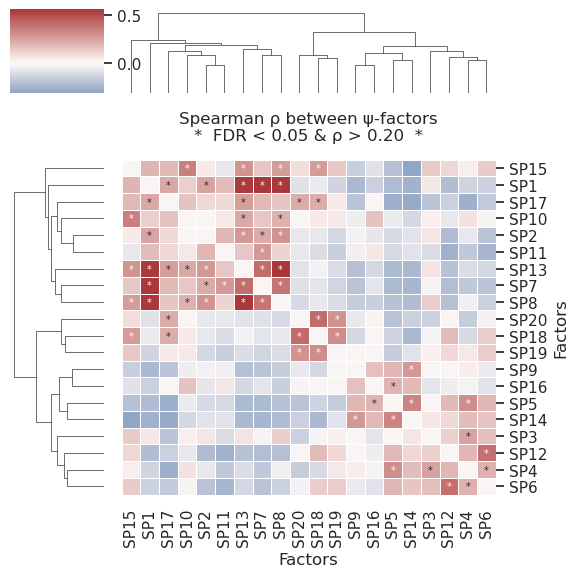

In [24]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests   # pip install statsmodels

# ── 1.  Data → DataFrame ───────────────────────────────────────────────────────
ψ  = splice_adata.varm["psi_learned"]          # (J, K)
K  = ψ.shape[1]

# Subtract row (junction) mean from each factor value
ψ_centered = ψ - np.nanmean(ψ, axis=1, keepdims=True)
K = ψ_centered.shape[1]
df = pd.DataFrame(ψ_centered, columns=[f"SP{j+1}" for j in range(K)])

# ── 2.  ρ and p-values for *each* pair ─────────────────────────────────────────
rho    = np.zeros((K, K))
pvals  = np.ones((K, K))

for i in range(K):
    for j in range(i+1, K):
        r, p = spearmanr(df.iloc[:, i], df.iloc[:, j], nan_policy='omit')
        rho[i, j] = rho[j, i] = r
        pvals[i, j] = pvals[j, i] = p

# ── 3.  Benjamini–Hochberg FDR adjustment over the upper triangle ─────────────
tri_idx         = np.triu_indices(K, k=1)          # exclude the diagonal
p_flat          = pvals[tri_idx]
_, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")
qvals           = np.ones_like(pvals)
qvals[tri_idx]  = qvals.T[tri_idx] = q_flat

# ── 4.  Significance mask  (FDR < 0.05 and ρ > 0.20) ──────────────────────────
star_mask = (qvals < 0.05) & (rho > 0.20)
annot     = np.where(star_mask, "*", "")

# ── 5.  Build DataFrames with indices/columns for seaborn ─────────────────────
rho_df   = pd.DataFrame(rho,   index=df.columns, columns=df.columns)
annot_df = pd.DataFrame(annot, index=df.columns, columns=df.columns)


# ── 1.  clustered heat-map with all tick labels ───────────────────────────────
sns.set_theme(style="white")
g = sns.clustermap(
    rho_df,
    cmap="vlag", center=0, linewidths=0.4, square=True,
    metric="euclidean", row_cluster=True, col_cluster=True,
    figsize=(6, 6),
    annot=annot_df, fmt="", annot_kws={"size":7},
    xticklabels=True, yticklabels=True
)

# Rotate x-labels so they don’t overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.ax_heatmap.set_title("Spearman ρ between ψ-factors\n*  FDR < 0.05 & ρ > 0.20  *", pad=14)
g.ax_heatmap.set_xlabel("Factors")
g.ax_heatmap.set_ylabel("Factors")

plt.tight_layout()

# ── 2.  save to disk ──────────────────────────────────────────────────────────
g.savefig(f"{OUTPUT_DIR}/psi_factor_spearman_clustermap.pdf", bbox_inches="tight")

# ── 3.  report extreme pairs ──────────────────────────────────────────────────
# flatten upper triangle (exclude diagonal), keep finite values only
tri_i, tri_j = np.triu_indices_from(rho_df, k=1)
tri_vals = rho_df.values[tri_i, tri_j]

# build a DataFrame for easy sorting
pairs_df = pd.DataFrame({
    "factor_i": rho_df.index[tri_i],
    "factor_j": rho_df.columns[tri_j],
    "rho":      tri_vals
}).dropna()

# top 2 positive
top_pos = pairs_df.nlargest(2, "rho")
# top 2 negative
top_neg = pairs_df.nsmallest(2, "rho")
# top 2 least correlated (closest to zero)
top_flat = pairs_df.iloc[(pairs_df["rho"].abs()).nsmallest(2).index]

print("\nTop 2 positively correlated factor pairs:")
print(top_pos.to_string(index=False))

print("\nTop 2 negatively correlated factor pairs:")
print(top_neg.to_string(index=False))

print("\nTop 2 least correlated factor pairs:")
print(top_flat.to_string(index=False))


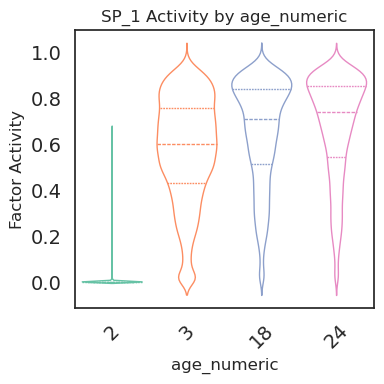

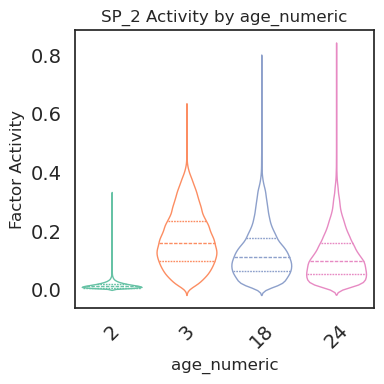

In [25]:
plot_factor_violin(
    adata=splice_adata,
    factor_list=["SP_1", "SP_2"],
    groupby="age_numeric",
    save_prefix="factor_age_violin"
)

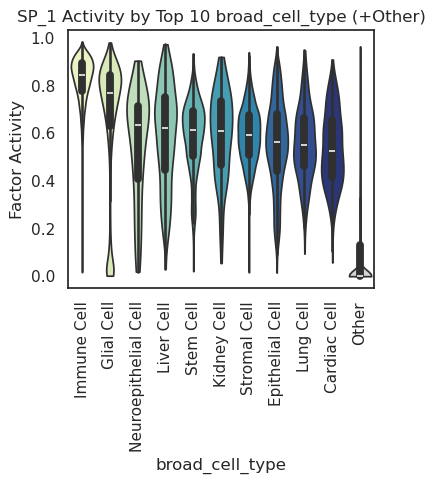

In [26]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_1"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

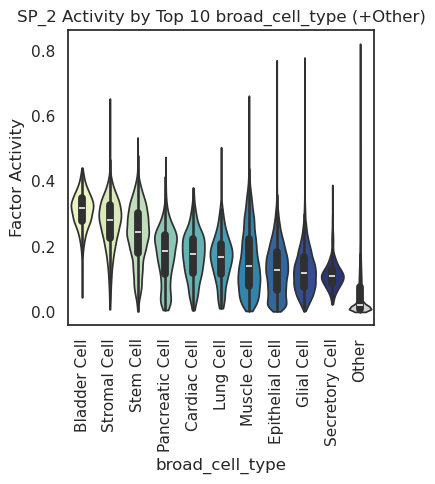

In [27]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_2"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

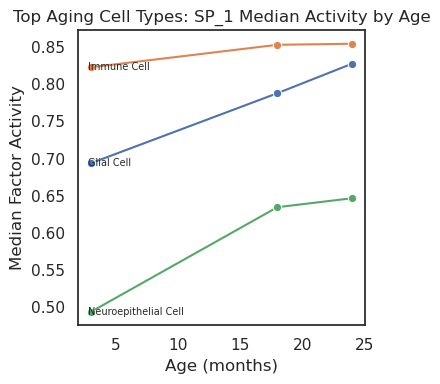

In [28]:
plot_factor_age_trends(
    df=splice_adata.obs[splice_adata.obs["age_numeric"] > 2],
    factor="SP_1",
    top_n=3,
    title_prefix="Top Aging Cell Types",
    save_path=f"{OUTPUT_DIR}/Factor_1_age_trend_top3.pdf"
)


### Get heatmap for common cell types 

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/clustering_common_celltype_dataset_factors.pdf


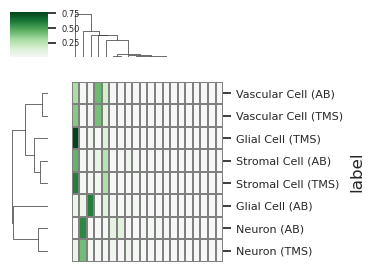

In [29]:
# Get cell type counts by dataset to get common cell types
# Get cell type counts by dataset to get common cell types
cell_type_counts = splice_adata.obs.groupby(['broad_cell_type', 'dataset']).size().unstack()
common_cell_types = cell_type_counts[(cell_type_counts["AB"] > 0) & (cell_type_counts["TMS"] > 0)]
common_cell_type_names = common_cell_types.index.tolist()

# Subset to common cell types
adata_common = splice_adata[
    splice_adata.obs["broad_cell_type"].isin(common_cell_type_names)
].copy()

# Convert to categorical first
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].astype("category")
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].cat.remove_unused_categories()

# Extract factor matrix and build DataFrame
num_factors = adata_common.obsm["X_PHI"].shape[1]
factor_cols = [f"Factor_{i+1}" for i in range(num_factors)]

df = adata_common.obs[["broad_cell_type", "dataset"]].copy()
for i, col in enumerate(factor_cols):
    df[col] = adata_common.obsm["X_PHI"][:, i]

# Compute median factor values by cell type and dataset
median_profiles = (
    df.groupby(["broad_cell_type", "dataset"], observed=True)[factor_cols]
    .median()
    .reset_index()
)

# Create composite labels
median_profiles["label"] = (
    median_profiles["broad_cell_type"].astype(str)
    + " (" +
    median_profiles["dataset"].astype(str)
    + ")"
)

# Set label as index
median_profiles = median_profiles.set_index("label")[factor_cols]

# Plot clustermap
g = sns.clustermap(
    median_profiles,
    method="average",
    metric="euclidean",
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor='gray',
    figsize=(4, 3)
)

# Remove x-axis tick labels (factors)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xticklabels([])

# Format y-axis (cell types)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)

# Colorbar label and tick font
g.ax_cbar.set_label("Median Factor Activity")
g.ax_cbar.yaxis.label.set_size(7)
g.ax_cbar.tick_params(labelsize=6)

# Save
plt.tight_layout()
g.savefig(f"{OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf", bbox_inches='tight')
print(f"Saved plot to {OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf")
plt.show()

In [30]:
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].astype("category")
splice_adata.obs["medium_cell_type"] = splice_adata.obs["medium_cell_type"].astype("category")

  broad_cell_type age_numeric      SP_3
0          Neuron           2  0.565610
1          Neuron           3  0.510364
2          Neuron          18  0.206852
3          Neuron          24  0.455628


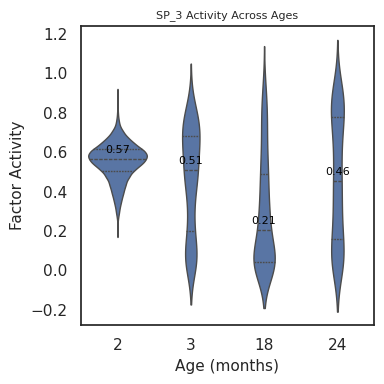

In [31]:
plot_factor_violin_by_age(
    df=splice_adata.obs,
    factor="SP_3",
    cell_types=["Neuron"],
    figsize=(4, 4), save_path=f"{OUTPUT_DIR}/F10_SecretoryCells.pdf"
)


  broad_cell_type age_numeric      SP_4
0          Neuron           2  0.084799
1          Neuron           3  0.049095
2          Neuron          18  0.022933
3          Neuron          24  0.023437


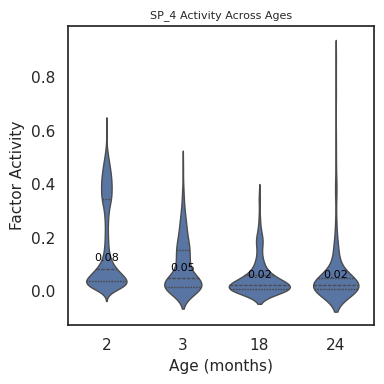

In [32]:
plot_factor_violin_by_age(
    df=splice_adata.obs,
    factor="SP_4",
    cell_types=["Neuron"],
    figsize=(4, 4), save_path=f"{OUTPUT_DIR}/F10_SecretoryCells.pdf"
)


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Extract age and perplexity
X = splice_adata.obs[["age_numeric"]].values  # shape (n_cells, 1)
y = splice_adata.obs["perplexity"].values  # shape (n_cells,)

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Compute R²
r2 = r2_score(y, y_pred)
print(f"R² (perplexity ~ age): {r2:.4f}")

R² (perplexity ~ age): 0.1221


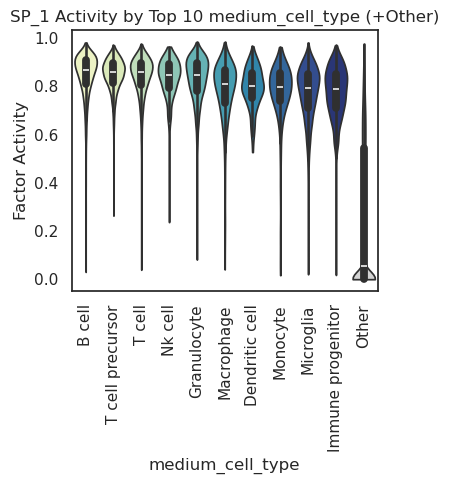

In [34]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_1"],
    groupby="medium_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


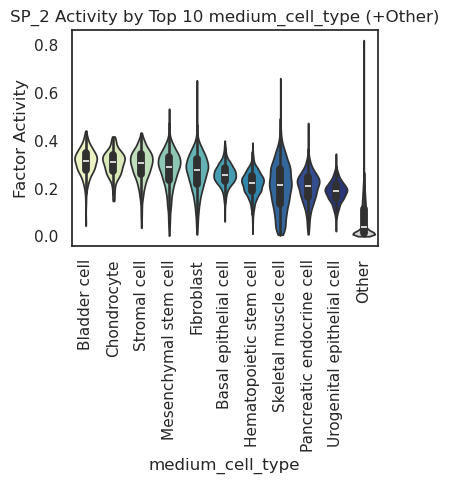

In [35]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_2"],
    groupby="medium_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


## Look at sig junctions from differential splicing analysis

In [36]:
# Run the analysis
print("="*60)
print("TOP JUNCTIONS PER FACTOR PSI ANALYSIS")
print("="*60)

# Step 1: Get top junctions per factor
top_junctions_dict, subset_splice_adata, junction_factor_map = get_top_junctions_per_factor(
    diff_spl, 
    splice_adata, 
    top_n=10, 
    effect_size_col='abs_effect_size'
)

# Get unique junction indices
unique_junctions = junction_factor_map['junction_idx'].unique()

# Extract PSI learned values for these junctions
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]

TOP JUNCTIONS PER FACTOR PSI ANALYSIS
Getting top 10 junctions per factor...
Ranking by: abs_effect_size
Found 20 factors: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Factor 0: 10 junctions, effect size range: 0.961 - 0.991
Factor 1: 10 junctions, effect size range: 0.851 - 0.916
Factor 2: 10 junctions, effect size range: 0.782 - 0.905
Factor 3: 10 junctions, effect size range: 0.907 - 0.959
Factor 4: 10 junctions, effect size range: 0.920 - 0.966
Factor 5: 10 junctions, effect size range: 0.894 - 0.953
Factor 6: 10 junctions, effect size range: 0.979 - 0.997
Factor 7: 10 junctions, effect size range: 0.971 - 0.990
Factor 8: 10 junctions, effect size range: 0.915 - 0.974
Factor 9: 10 junctions, effect size range: 0.798 - 0.913
Factor 10: 10 junctions, effect size range: 0.943 - 0.985
Factor 11: 10 junctions, effect size range: 0.910 - 0.969
Factor 12: 10 junctions, effect size range: 0.937 - 0.989
Factor 13: 10 junctions, effect size range: 0.891 - 0.921
Fact

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/psi_clustermap_top_10.pdf


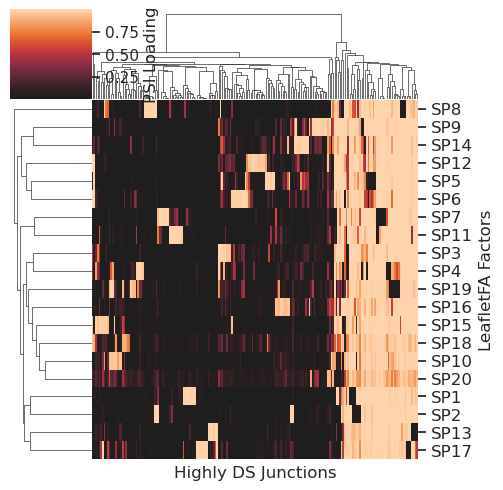

In [37]:
# 1. Map row labels: get junction_id or gene_name from .var
# Get the integer indices into .varm (which uses original order)
unique_junctions = junction_factor_map['junction_idx'].unique()
# psi_learned: shape (n_junctions, n_factors), so index using integer indices
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]
junction_id = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["junction_id"].values
gene_name = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["gene_name"].values

# Get number of factors (rows after transpose)
num_factors = psi_subset.shape[1]

# Create factor labels: F1, F2, ..., FK
factor_labels = [f"SP{i+1}" for i in range(num_factors)]

# 2. Create clustermap with color tweaks
g = sns.clustermap(
    psi_subset.T,
    center=0,
    figsize=(6, 5),
    xticklabels=False,
    yticklabels=factor_labels,
    cbar_kws={'label': 'PSI Loading'},
    robust=True  # clip extreme values for better contrast
)

# 3. Style adjustments
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)
g.ax_heatmap.set_ylabel("LeafletFA Factors")
g.ax_heatmap.set_xlabel("Highly DS Junctions")
plt.subplots_adjust(left=0.3, bottom=0.05, top=0.95, right=0.98)
save_path = os.path.join(OUTPUT_DIR, "psi_clustermap_top_10.pdf")
g.savefig(save_path, bbox_inches="tight")
print(f"Saved plot to {save_path}")
plt.show()

## Get UMAP on X_PHI

In [38]:
ge_adata.layers["scVI_linear"] = ge_adata.obsm["X_normalized_scVI_linear"]

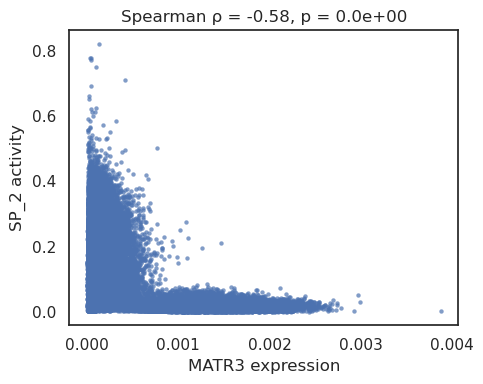

In [39]:
plot_gene_vs_factor_correlation(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    layer = "scVI_linear",
    gene_name="MATR3",
    factor_col="SP_2",
    plot_type="scatter"  # try "hist", "kde", or "hist"
)

In [40]:
# Run neighbors and UMAP on X_PHI embedding
# sc.pp.neighbors(filtered_splice_adata, use_rep="X_PHI", n_neighbors=8)
# sc.tl.umap(filtered_splice_adata, random_state=0, min_dist=0.3)

In [41]:
#plot_gene_and_factor_umap_from_phi(
#    splice_adata=filtered_splice_adata,
#    ge_adata=filtered_ge_adata,
#    gene_name="ZWINT",
#    factor_name="Factor_2",
#    groupby="broad_cell_type",
#    group_level="Microglia"
#)

In [42]:
splice_adata.obs["SP_1"]

cell_id
A10_B000120          0.542713
A10_B000126          0.627915
A10_B000127          0.692698
A10_B000166          0.542995
A10_B000169          0.325281
                       ...   
US-1250275_E2_S86    0.001478
US-1250275_E2_S87    0.001557
US-1250275_E2_S88    0.001420
US-1250275_E2_S89    0.004546
US-1250275_E2_S90    0.001756
Name: SP_1, Length: 137893, dtype: float64

In [43]:
ge_adata.obs["SP_1"] = splice_adata.obs["SP_1"]
ge_adata.obs["SP_2"] = splice_adata.obs["SP_2"]

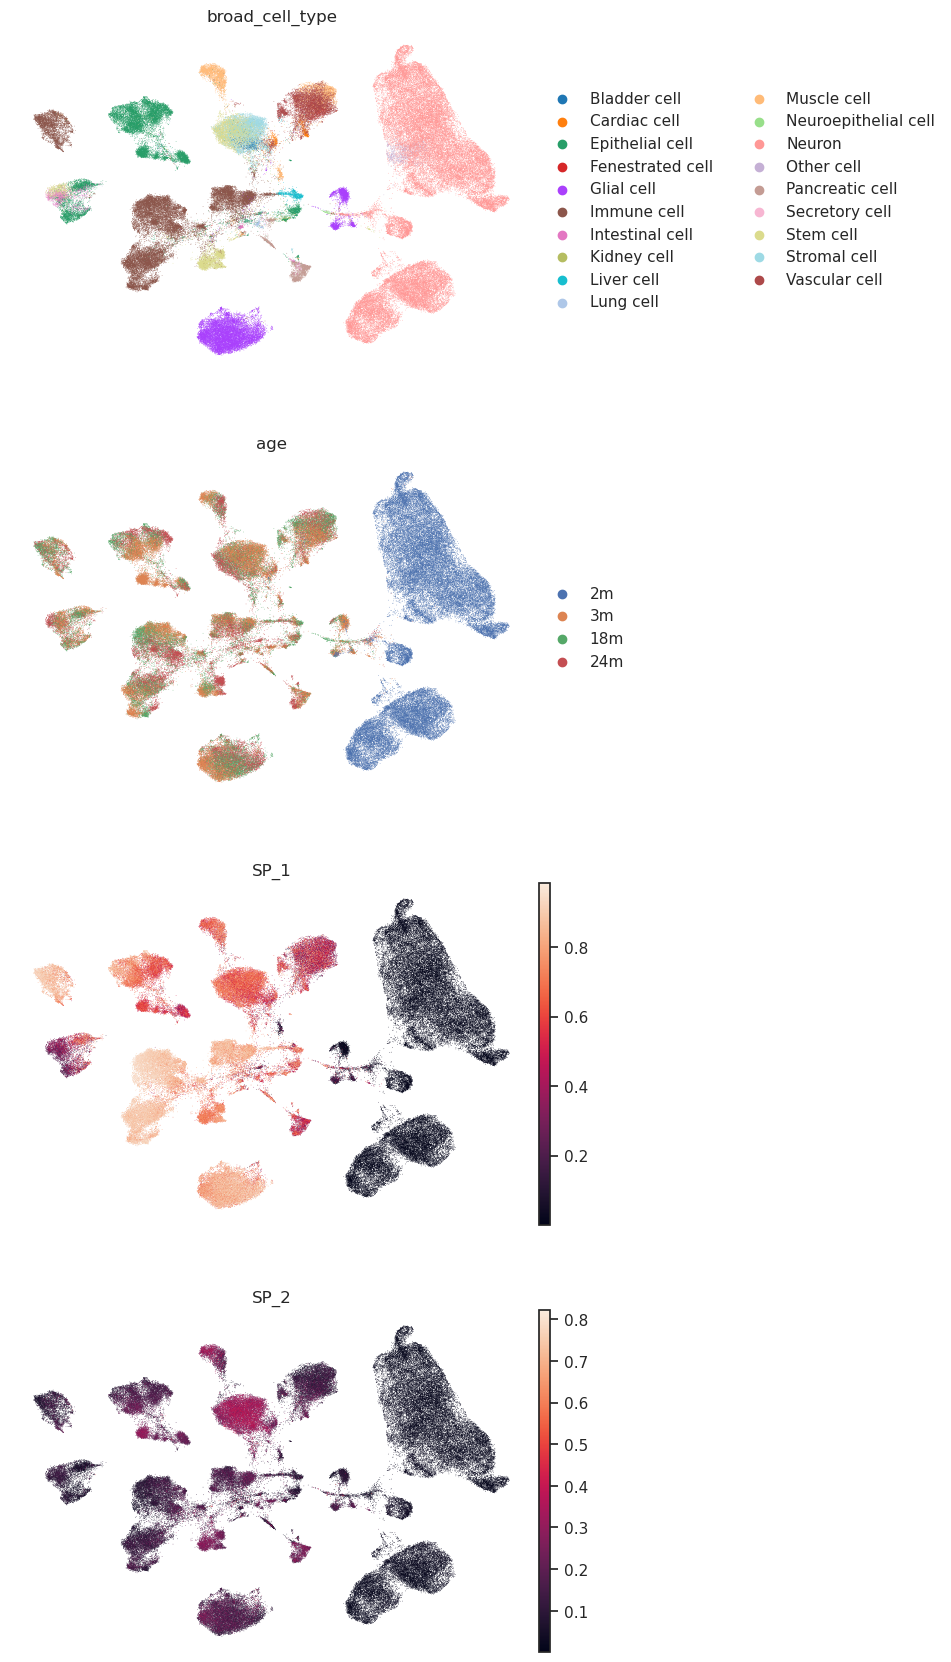

In [44]:
# Multiple plots in one figure
sc.pl.umap(ge_adata, 
           color=['broad_cell_type', 'age', 'SP_1', 'SP_2'],
           ncols=1,
           frameon=False,
           save='_multiplot.pdf')

### New circle heatmap combining delta age and activity across cell types

In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.patches import Circle, Rectangle
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_factor_circles(adata, cell_type_col='broad_cell_type', age_col='age_group'):
    """
    Clustered tile plot: background color shows delta PSI (old - young),
    circle outlines show activity (median nonzero expression).
    """
    # Extract factor matrix
    X_PHI = adata.obsm["X_PHI"]
    n_factors = X_PHI.shape[1]
    factor_cols = [f"SP_{i+1}" for i in range(n_factors)]
    factor_df = pd.DataFrame(X_PHI, index=adata.obs.index, columns=factor_cols)

    # Median expression (non-zero) per cell type
    median_expr = pd.DataFrame(index=adata.obs[cell_type_col].unique(), columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        ct_data = factor_df.loc[ct_mask]
        for factor in factor_cols:
            vals = ct_data[factor]
            nonzero = vals[vals > 0]
            median_expr.loc[ct, factor] = nonzero.median() if len(nonzero) > 0 else 0
    median_expr = median_expr.astype(float).fillna(0)

    # Delta PSI: old - young
    delta_age = pd.DataFrame(index=median_expr.index, columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        old_mask = ct_mask & (adata.obs[age_col] == 'old')
        young_mask = ct_mask & (adata.obs[age_col] == 'young')
        if old_mask.sum() > 10 and young_mask.sum() > 10:
            for factor in factor_cols:
                old_vals = factor_df.loc[old_mask, factor]
                young_vals = factor_df.loc[young_mask, factor]
                delta_age.loc[ct, factor] = old_vals.median() - young_vals.median()
        else:
            delta_age.loc[ct] = 0
    delta_age = delta_age.astype(float).fillna(0)

    # Clustering
    factor_order = list(range(len(factor_cols)))  # preserve original SP_1 ... SP_K order
    celltype_order = dendrogram(linkage(median_expr, method='ward'), no_plot=True)['leaves']
    celltype_order = [median_expr.index[i] for i in celltype_order]

    # Compute cell counts
    celltype_counts = adata.obs[cell_type_col].value_counts()
    celltype_labels = [f"{ct} ({celltype_counts[ct]})" for ct in celltype_order]

    # Reorder matrices
    median_ordered = median_expr.loc[celltype_order, :].iloc[:, factor_order]
    delta_ordered = delta_age.loc[celltype_order, :].iloc[:, factor_order]

    # Plot setup
    fig, ax = plt.subplots(figsize=(10, 7))
    n_cells = len(median_ordered)
    n_factors = len(median_ordered.columns)
    ax.set_xlim(-0.5, n_factors - 0.5)
    ax.set_ylim(-0.5, n_cells - 0.5)

    # Color scale for delta PSI
    cmap = plt.cm.BrBG
    vmax = max(abs(delta_ordered.values.min()), abs(delta_ordered.values.max()))
    norm = plt.Normalize(vmin=-vmax, vmax=vmax)

    # Draw tiles
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            delta = delta_ordered.loc[cell_type, factor]
            color = cmap(norm(delta))
            tile = Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='none')
            ax.add_patch(tile)

    # Draw circle outlines for activity
    min_radius = 0.1
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            expr = median_ordered.loc[cell_type, factor]
            if expr > 0.001:
                radius = max(min_radius, (np.log10(expr + 0.01) + 2) * 0.15)
                delta = delta_ordered.loc[cell_type, factor]
                color = cmap(norm(delta))  # match background
                circle = Circle((j, i), radius, facecolor=color, edgecolor='black', linewidth=0.4)
                ax.add_patch(circle)

    # Axis labels
    ax.set_xticks(range(n_factors))
    ax.set_xticklabels(median_ordered.columns, rotation=90, fontsize=10)
    ax.set_yticks(range(n_cells))
    ax.set_yticklabels(celltype_labels, fontsize=10)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False)
    ax.grid(False)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Δ SP Activity (old - young)', shrink=0.3)

    from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox, VPacker, HPacker, TextArea

    # Legend values (representative activity levels)
    example_exprs = [0.01, 0.1, 1.0]

    # Function to compute radius in axis units
    def compute_radius(val):
        return max(min_radius, (np.log10(val + 0.01) + 2) * 0.15)

    # Build legend items
    legend_items = []
    for val in example_exprs:
        radius = compute_radius(val)

        # Circle scaled correctly in data units
        circle_box = AuxTransformBox(ax.transData)
        circle = Circle((0, 0), radius, facecolor='white', edgecolor='black', linewidth=0.6)
        circle_box.add_artist(circle)

        # Label
        label = TextArea(f"{val:.2f}", textprops=dict(fontsize=8, va='center', ha='left'))

        # Combine horizontally: [circle | label]
        item = HPacker(children=[circle_box, label], align="center", pad=0, sep=5)
        legend_items.append(item)

    # Combine all items vertically
    legend_box = VPacker(children=legend_items, align="left", pad=0, sep=6)

    # Place the anchored box
    anchored_legend = AnchoredOffsetbox(
        loc='upper right',
        child=legend_box,
        frameon=True,
        bbox_to_anchor=(1.25, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=0.5,
        pad=0.5
    )
    ax.add_artist(anchored_legend)

    plt.tight_layout()
    return fig

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/delta_median_old_minus_young_by_broad_cell_type_dot_heatmap.pdf


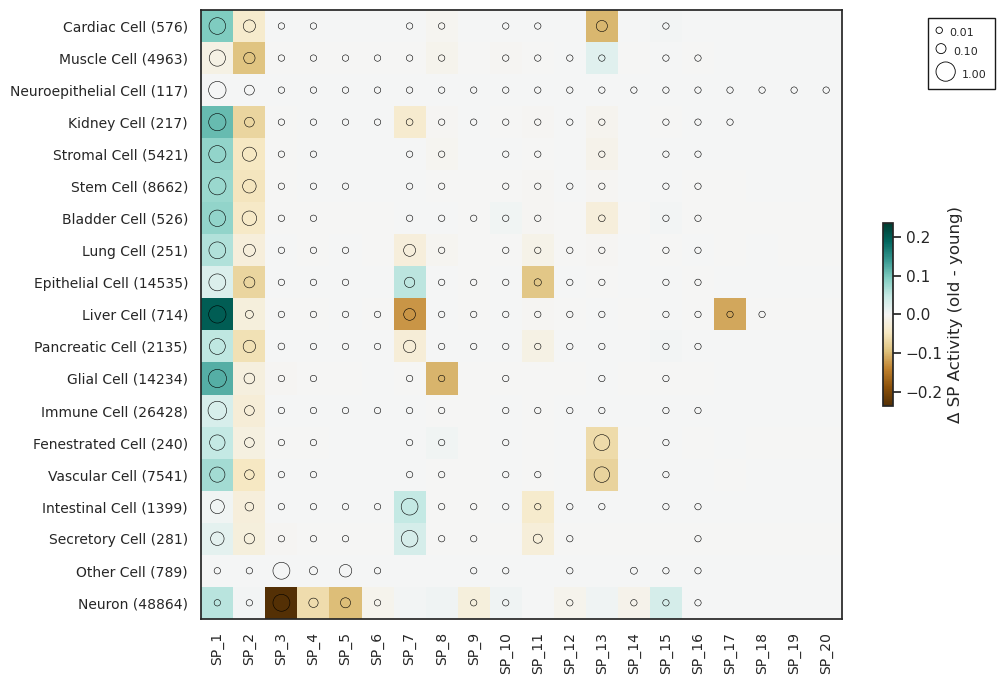

In [46]:
cell_type_col = "broad_cell_type"
fig = plot_factor_circles(splice_adata, cell_type_col=cell_type_col)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/delta_median_old_minus_young_by_medium_cell_type_dot_heatmap.pdf


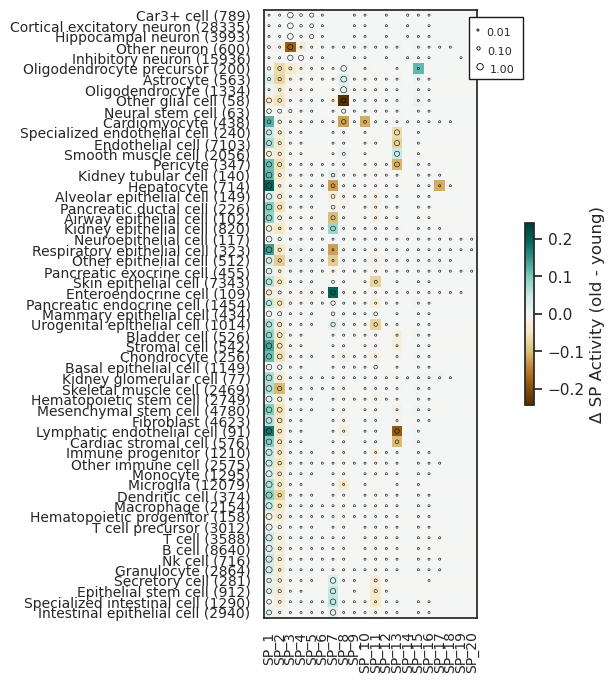

In [47]:
cell_type_col = "medium_cell_type"
fig = plot_factor_circles(splice_adata, cell_type_col=cell_type_col)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

In [48]:
def plot_factor_junction_annotation_counts(final_df, output_path):
    """
    Create a stacked barplot showing the number of significant junctions per factor,
    colored by junction annotation category.
    """
    # Count unique junctions by (factor, annotation)
    counts = (
        final_df.groupby(["factor_idx", "junction_annotation"])["junction_id_index"]
        .nunique()
        .reset_index(name="count")
    )
    # Add factor name column
    counts["factor_name"] = "SP_" + (counts["factor_idx"] +1).astype(str)
    # Pivot to wide format: rows=factor_name, columns=annotation, values=count
    pivot_df = counts.pivot(index="factor_name", columns="junction_annotation", values="count").fillna(0)
    # print table
    print(pivot_df)
    # Sort by total number of junctions
    pivot_df["total"] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values("total", ascending=False)
    pivot_df = pivot_df.drop(columns="total")
    # Plot
    plt.figure(figsize=(5, 3))
    pivot_df.plot(
        kind="bar",
        stacked=True,
        colormap="viridis",  # Or use sns.color_palette("Set2", n_colors=...)
        edgecolor="black"
    )
    plt.xlabel("Splicing Program", fontsize=12)
    plt.ylabel("# of Significant Junctions", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="Junction Annotation", fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    # Save
    plt.savefig(output_path, dpi=300)
    print(f"Saved to {output_path}")
    plt.show()
    plt.close()

In [49]:
def plot_junction_factor_distribution(final_df, output_path):
    """Create an improved histogram showing distribution of factors per junction"""
    # Get counts of factors/junction
    junc_counts = final_df.groupby("junction_id_index")["factor_idx"].nunique()
    junc_counts_df = pd.DataFrame({"junction_id_index": junc_counts.index, "num_factors": junc_counts.values})
    # Create figure with appropriate size
    plt.figure(figsize=(5, 4))
    # Create histogram with better styling
    ax = sns.histplot(junc_counts_df["num_factors"], bins=range(1, junc_counts_df["num_factors"].max() + 2), 
                     kde=True, color='steelblue', edgecolor='darkblue', alpha=0.7)
    # Add mean line
    mean_factors = junc_counts_df["num_factors"].mean()
    plt.axvline(mean_factors, color='red', linestyle='--', linewidth=2)
    plt.text(mean_factors + 0.2, plt.ylim()[1]*0.9, f'Mean: {mean_factors:.2f}', 
             color='red', fontweight='bold')
    # Add title and labels with better formatting
    plt.xlabel("# of Splicing Programs with Significant \nEffect on Junction", fontsize=12)
    plt.ylabel("# of junctions", fontsize=12)
    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3)
    # increase tick font size 
    # Adjust layout
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    # Save figure with higher DPI
    plt.savefig(output_path, dpi=300)
    print(f"Saved to {output_path}")
    plt.show()
    plt.close()

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/differential_splicing_barplot.pdf


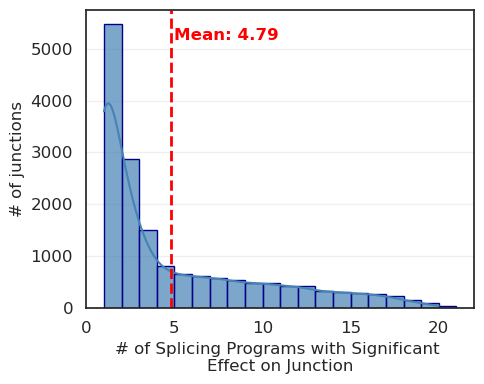

In [50]:
plot_junction_factor_distribution(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_barplot.pdf"))

junction_annotation  3_prime_annotated  5_prime_annotated  Both_SS_annotated  \
factor_name                                                                    
SP_1                             207.0              171.0             5058.0   
SP_10                             90.0               80.0             2006.0   
SP_11                            192.0              197.0             4832.0   
SP_12                            253.0              295.0             4252.0   
SP_13                            162.0              144.0             4025.0   
SP_14                            308.0              311.0             5133.0   
SP_15                            114.0              114.0             3245.0   
SP_16                            117.0              115.0             1929.0   
SP_17                            131.0              115.0             2397.0   
SP_18                             24.0               24.0              617.0   
SP_19                             80.0  

<Figure size 500x300 with 0 Axes>

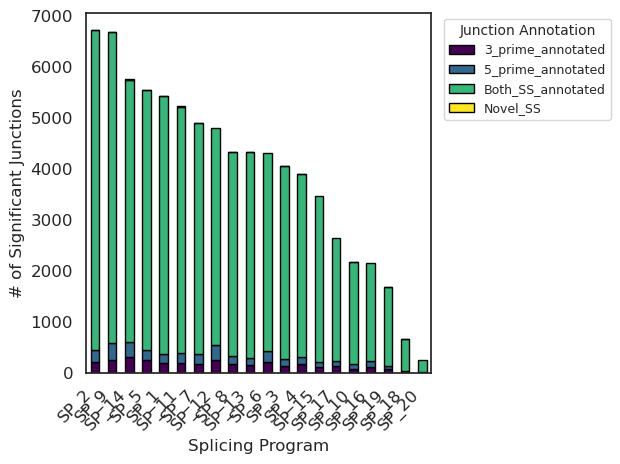

In [51]:
plot_factor_junction_annotation_counts(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_annotation_type_barplot.pdf"))

## Recalculate differential splicing junctions

In [52]:
# Reset junction_id_index column 
psi_samples = leaflet_model["psi_samples"]
splice_adata.var["junction_id_index"] = np.arange(splice_adata.n_vars)
print("\n>> Running analysis functions...")
results = ds.analyze_all_factors_psi(psi_samples, top_junctions=splice_adata.var["junction_id_index"].values, min_effect_size=0.2)
all_results = []

for factor_idx, (effect_size_list, significance_df) in results.items():
    # Append to list
    all_results.append(significance_df)
    print("\n>> Running analysis functions...")

# Concatenate all results into a single DataFrame
final_df = pd.concat(all_results, ignore_index=True)
final_df["junction_id_index"] = final_df["junction_idx"]
# convert splice_adata.var["junction_id_index"] to dtype int64
splice_adata.var["junction_id_index"] = splice_adata.var["junction_id_index"].astype("int64")



>> Running analysis functions...
Analyzing differential splicing for 20 factors...
Finding DS junctions in factor 0 vs. all others


100%|██████████| 35197/35197 [00:06<00:00, 5151.64it/s]


Found 6726 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 1 vs. all others


100%|██████████| 35197/35197 [00:06<00:00, 5452.30it/s]


Found 4067 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 2 vs. all others


...

Found 670 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 18 vs. all others


100%|██████████| 35197/35197 [00:06<00:00, 5445.39it/s]


Found 1685 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 19 vs. all others


100%|██████████| 35197/35197 [00:06<00:00, 5581.05it/s]


Found 260 significant junctions with effect size > 0.2 at FDR < 0.05

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...


In [53]:
final_df

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,psi_factor_mean,psi_nonfactor_mean,fdr_curve,n_significant,junction_id_index
0,0,0,0.020312,0.020312,0.000079,0.0,0.00,1.00,False,0.2,0.994989,0.974677,0.783990,6726,0
1,0,1,-0.020029,0.020029,0.056855,11.0,0.11,0.89,False,0.2,0.078130,0.098159,0.220359,6726,1
2,0,2,0.344711,0.344711,0.000601,100.0,1.00,0.00,True,0.2,0.987477,0.642766,0.000000,6726,2
3,0,3,-0.199744,0.199744,0.000549,42.0,0.42,0.58,False,0.2,0.003050,0.202794,0.102008,6726,3
4,0,4,0.357117,0.357117,0.000835,100.0,1.00,0.00,True,0.2,0.986733,0.629616,0.000000,6726,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703935,19,35192,-0.006474,0.006474,0.000414,0.0,0.00,1.00,False,0.2,0.988908,0.995382,0.745758,260,35192
703936,19,35193,0.008755,0.008755,0.020918,6.0,0.06,0.94,False,0.2,0.047957,0.039202,0.629234,260,35193
703937,19,35194,-0.033106,0.033106,0.028236,26.0,0.26,0.74,False,0.2,0.578394,0.611500,0.370918,260,35194
703938,19,35195,0.030557,0.030557,0.018484,5.0,0.05,0.95,False,0.2,0.042034,0.011477,0.630090,260,35195


In [54]:
# Step 2: Rename and map
final_df = final_df.rename(columns={"factor_idx": "old_factor_idx"})
final_df["factor_idx"] = final_df["old_factor_idx"].map(old_to_new_factor_idx)

In [55]:
# Merge with adata.var using junction_id_index
final_df = final_df.merge(splice_adata.var, on="junction_id_index")

In [56]:
final_df.iloc[1]

old_factor_idx                                         0
junction_idx                                           1
effect_size                                    -0.020029
abs_effect_size                                 0.020029
effect_size_var                                 0.056855
num_greater                                         11.0
prob_greater                                        0.11
prob_lessoreq                                       0.89
significant                                        False
delta                                                0.2
psi_factor_mean                                  0.07813
psi_nonfactor_mean                              0.098159
fdr_curve                                       0.220359
n_significant                                       6726
junction_id_index                                      1
factor_idx                                             1
junction_id                  chr10_100016155_100051845_+
event_id                    ENS

In [57]:
# Create boolean masks for gene types
is_aging_gene = final_df["gene_name"].isin(aging_genes_mouse)
is_rbp_gene = final_df["gene_name"].isin(rbps)

# Initialize junction_label with 'Other'
final_df["junction_label"] = "Other"
final_df.loc[is_rbp_gene, "junction_label"] = "RBP"
final_df.loc[is_aging_gene, "junction_label"] = "Aging"

# Set 'Aging+RBP' if it's both (this will overwrite 'Aging' or 'RBP' if applicable)
final_df.loc[is_aging_gene & is_rbp_gene, "junction_label"] = "Aging+RBP"
print(final_df.junction_label.value_counts())

junction_label
Other        669280
RBP           21620
Aging         10540
Aging+RBP      2500
Name: count, dtype: int64


In [58]:
final_df = final_df.merge(atse_df, on="junction_id")

In [59]:
def plot_individual_factor_junction_analysis(final_df, results_dir, top_n=50):
    """
    Create individual plots for each factor showing their effect on top junctions.
    
    Args:
        final_df: DataFrame with columns ['junction_id_index', 'gene_name', 'junction_label', 'factor_idx', 'effect_size']
        results_dir: Base results directory
        top_n: Number of top junctions to show per factor
    """
    
    # Create DS_FACTORS directory
    ds_factors_dir = os.path.join(results_dir, "DS_FACTORS")
    os.makedirs(ds_factors_dir, exist_ok=True)
    print(f"Creating individual factor plots in: {ds_factors_dir}")
    
    # Junction type color mapping
    label_colors_map = {"Aging": "gold", "RBP": "lightgreen", "Aging+RBP": "orange", "Other": "lightgray"}
    
    # Get unique factors
    unique_factors = sorted(final_df["factor_idx"].unique())
    print(f"Found {len(unique_factors)} factors to analyze")
    
    for factor_idx in unique_factors:
        
        print(f"  Processing Factor_{factor_idx+1}...")
        
        # Filter data for this factor
        factor_df = final_df[final_df["factor_idx"] == factor_idx].copy()
        
        # Get top N junctions by absolute effect size for this factor
        factor_df["abs_effect_size"] = factor_df["effect_size"].abs()
        top_junctions = factor_df.nlargest(top_n, "abs_effect_size")
                
        # Create publication-ready plot with 3 subplots
        # Calculate height based on number of junctions (min 6", max 12")
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 7), 
                                            gridspec_kw={'width_ratios': [3.5, 1.25, 1.25]})
        
        # Set publication-ready style
        plt.rcParams.update({
            'font.size': 10,
            'axes.titlesize': 12,
            'axes.labelsize': 11,
            'xtick.labelsize': 9,
            'ytick.labelsize': 9,
            'legend.fontsize': 9,
            'figure.titlesize': 14
        })
        
        # ---- Left plot: Horizontal bar chart of effect sizes ----
        
        # Prepare data for plotting
        plot_data = top_junctions.copy()
        plot_data["display_label"] = plot_data.apply(
            lambda row: f"{row['gene_name_x']} (J{row['junction_id_index']})", axis=1
        )
        
        # Sort by effect size for better visualization
        plot_data = plot_data.sort_values("effect_size", ascending=True)
        
        # Create color array based on junction labels
        colors = [label_colors_map.get(label, "lightgray") for label in plot_data["junction_label"]]
        
        # Create horizontal bar plot with publication styling
        bars = ax1.barh(range(len(plot_data)), plot_data["effect_size"], 
                       color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
        
        # Customize left plot with publication standards
        ax1.set_yticks(range(len(plot_data)))
        ax1.set_yticklabels(plot_data["display_label"], fontsize=8)
        ax1.set_xlabel("Effect Size", fontsize=11, fontweight='bold')
        ax1.set_title(f"Factor {factor_idx+1}: Top {len(plot_data)} Affected Junctions", 
                     fontsize=12, fontweight='bold', pad=15)
        ax1.axvline(x=0, color='black', linestyle='-', linewidth=1.0)
        ax1.grid(axis='x', alpha=0.4, linewidth=0.5)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.spines['left'].set_linewidth(0.8)
        ax1.spines['bottom'].set_linewidth(0.8)
        
        # Add effect size values on bars with better formatting
        for i, (bar, effect) in enumerate(zip(bars, plot_data["effect_size"])):
            width = bar.get_width()
            x_pos = width + (0.02 if width >= 0 else -0.02)
            ha = 'left' if width >= 0 else 'right'
            ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{effect:.3f}', 
                    ha=ha, va='center', fontsize=7, fontweight='normal')
        
        # ---- Right plot 1: Junction type distribution ----
        
        # Count junction types
        type_counts = plot_data["junction_label"].value_counts()
        
        # Create publication-ready pie chart
        colors_pie = [label_colors_map.get(label, "lightgray") for label in type_counts.index]
        wedges, texts, autotexts = ax2.pie(type_counts.values, labels=type_counts.index, 
                                          colors=colors_pie, autopct='%1.1f%%', 
                                          startangle=90, textprops={'fontsize': 8},
                                          wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'})
        
        # Style the percentage labels
        for autotext in autotexts:
            autotext.set_color('black')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(8)
        
        ax2.set_title(f"Junction Type\n(n={len(plot_data)})", 
                     fontsize=10, fontweight='bold', pad=10)
        
        # ---- Right plot 2: Junction annotation distribution ----
        
        # Count junction annotations (if the column exists)
        if 'junction_annotation' in plot_data.columns:
            annotation_counts = plot_data["junction_annotation"].value_counts()
            
            # Create publication-ready color palette for annotations
            n_annotations = len(annotation_counts)
            annotation_colors = plt.cm.Set3(np.linspace(0, 1, n_annotations))
            
            # Create pie chart for annotations with publication styling
            wedges3, texts3, autotexts3 = ax3.pie(annotation_counts.values, 
                                                  labels=annotation_counts.index, 
                                                  colors=annotation_colors, 
                                                  autopct='%1.1f%%', 
                                                  startangle=90, 
                                                  textprops={'fontsize': 7},
                                                  wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'})
            
            # Style the percentage labels
            for autotext in autotexts3:
                autotext.set_color('black')
                autotext.set_fontweight('bold')
                autotext.set_fontsize(7)
            
            ax3.set_title(f"Junction Annotation\n(n={len(plot_data)})", 
                         fontsize=10, fontweight='bold', pad=10)
        else:
            # If junction_annotation column doesn't exist, show a clean message
            ax3.text(0.5, 0.5, 'Junction annotation\ndata not available', 
                    ha='center', va='center', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', 
                             alpha=0.3, edgecolor='gray', linewidth=0.8))
            ax3.set_title("Junction Annotation", fontsize=10, fontweight='bold', pad=10)
            ax3.set_xlim(-1, 1)
            ax3.set_ylim(-1, 1)
            ax3.axis('off')
                
        # ---- Create publication-ready legend ----
        
        # Create legend for junction types
        legend_handles = [plt.Rectangle((0,0),1,1, color=color, label=label, 
                                       edgecolor='black', linewidth=0.5) 
                         for label, color in label_colors_map.items() 
                         if label in plot_data["junction_label"].values]
        
        if legend_handles:  # Only create legend if there are items
            fig.legend(handles=legend_handles, 
                      title="Junction Type", 
                      loc="lower center", 
                      bbox_to_anchor=(0.5, -0.02),
                      ncol=min(4, len(legend_handles)),
                      frameon=True, 
                      fontsize=9, 
                      title_fontsize=10,
                      edgecolor='black',
                      fancybox=True,
                      shadow=True)
        
        # ---- Save publication-ready plot ----
        
        plt.tight_layout(rect=[0, 0.08, 1, 0.97])  # Better spacing for publication
        
        output_path = os.path.join(ds_factors_dir, f"Factor_{factor_idx+1}_junction_analysis.pdf")
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.close()
        
        print(f"    ✓ Saved: factor_{factor_idx+1}_junction_analysis.pdf")
            
        # ---- Make junction-specific clustermap ----
            
        print(f"    Creating junction-specific clustermap for factor_{factor_idx+1}...")
            
        # Get the top junction IDs for this factor
        top_junction_ids = top_junctions["junction_id_index"].unique()
            
        # Filter final_df to get ALL factor effects on these specific junctions
        junction_specific_df = final_df[final_df["junction_id_index"].isin(top_junction_ids)].copy()
            
        if not junction_specific_df.empty and len(junction_specific_df["factor_idx"].unique()) > 1:
            # Create pivot table: rows=junctions, columns=factors, values=effect_size
            clustermap_data = junction_specific_df.pivot_table(
                index=["junction_id_index", "gene_name_x", "junction_label"],
                columns="factor_idx",
                values="effect_size",
                fill_value=0
            )
            
            # Rename columns to include "factor_" prefix
            clustermap_data.columns = [f"Factor_{col+1}" for col in clustermap_data.columns]
            
            # Prepare row colors based on junction_label
            junction_types_for_colors = clustermap_data.index.get_level_values("junction_label")
            row_color_series = junction_types_for_colors.map(label_colors_map).rename("Junction Type")
            row_colors_df = row_color_series.to_frame()
            
            # Prepare display labels for y-axis
            display_row_labels = [f"{gene} (J{jid})" for jid, gene, _ in clustermap_data.index]
            clustermap_data_display = clustermap_data.copy()
            clustermap_data_display.index = display_row_labels
            row_colors_df.index = display_row_labels
            
            g = sns.clustermap(
                clustermap_data_display,
                row_colors=row_colors_df,
                cmap="RdBu_r",
                center=0,
                annot=False,
                linewidths=0.3,
                figsize=(6, 7),
                cbar_kws={'label': 'Effect Size'},
                xticklabels=True,
                yticklabels=True
            )
            
            # Highlight the current factor column
            current_factor_col = f"Factor_{factor_idx+1}"
            if current_factor_col in clustermap_data_display.columns:
                # Find the position of the current factor in the reordered columns
                col_order = g.dendrogram_col.reordered_ind
                reordered_cols = clustermap_data_display.columns[col_order]
                if current_factor_col in reordered_cols:
                    highlight_pos = list(reordered_cols).index(current_factor_col)
                    
                    # Add a thick border around the highlighted column
                    ax_heatmap = g.ax_heatmap
                    ax_heatmap.axvline(x=highlight_pos, color='yellow', linewidth=3, alpha=0.8)
                    ax_heatmap.axvline(x=highlight_pos + 1, color='yellow', linewidth=3, alpha=0.8)
            
            # Customize the plot
            plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
            plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
            
            # Add title
            g.fig.suptitle(f'All Factor Effects on Top {len(top_junction_ids)} Junctions from Factor {factor_idx+1}\\n(Yellow highlight = Factor {factor_idx})', 
                          fontsize=12, fontweight='bold', y=0.98)
            
            # Create legend for junction types
            legend_handles = [plt.Rectangle((0,0),1,1, color=color, label=label) 
                             for label, color in label_colors_map.items() 
                             if label in junction_types_for_colors.values]
            
            g.fig.legend(handles=legend_handles, 
                        title="Junction Type", 
                        loc="upper left", 
                        bbox_to_anchor=(0.02, 0.95),
                        frameon=True, 
                        fontsize=9, 
                        title_fontsize=10)
            
            # Save the clustermap
            clustermap_path = os.path.join(ds_factors_dir, f"Factor_{factor_idx+1}_junction_clustermap.pdf")
            g.savefig(clustermap_path, dpi=300, bbox_inches='tight')
            plt.close(g.fig)
            
            print(f"    ✓ Saved junction clustermap: Factor_{factor_idx+1}_junction_clustermap.pdf")
        else:
            print(f"    ⚠️ Insufficient data for clustermap (factor_{factor_idx})")
        
        print(f"    ✓ Completed analysis for Factor_{factor_idx+1}")
        print()
        
    return ds_factors_dir

In [60]:
final_df["gene_name_x"]

0          KITL
1          KITL
2          KITL
3          KITL
4          KITL
          ...  
703935    DDX3Y
703936    KDM5D
703937    KDM5D
703938    KDM5D
703939    KDM5D
Name: gene_name_x, Length: 703940, dtype: category
Categories (7179, object): ['0610009B22RIK', '0610010F05RIK', '0610037L13RIK', '1110004F10RIK', ..., 'ZWINT', 'ZYG11B', 'ZYX', 'ZZZ3']

In [61]:
final_df

,old_factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
0,0,0,0.020312,0.020312,0.000079,0.0,0.00,1.00,False,0.2,...,0.9938,0.9752,213472,217533,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1,0,1,-0.020029,0.020029,0.056855,11.0,0.11,0.89,False,0.2,...,0.0242,1.0000,217533,5258,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
2,0,2,0.344711,0.344711,0.000601,100.0,1.00,0.00,True,0.2,...,0.6404,1.0000,313794,200962,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
3,0,3,-0.199744,0.199744,0.000549,42.0,0.42,0.58,False,0.2,...,0.3570,0.3793,313794,295362,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
4,0,4,0.357117,0.357117,0.000835,100.0,1.00,0.00,True,0.2,...,1.0000,0.6170,182253,295362,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703935,19,35192,-0.006474,0.006474,0.000414,0.0,0.00,1.00,False,0.2,...,0.9915,0.9822,98883,99812,GT-AG,GT,AG,1.0,0.0,Both_SS_annotated
703936,19,35193,0.008755,0.008755,0.020918,6.0,0.06,0.94,False,0.2,...,0.0551,1.0000,55172,3040,GT-AG,GT,AG,NaN,1.0,3_prime_annotated
703937,19,35194,-0.033106,0.033106,0.028236,26.0,0.26,0.74,False,0.2,...,0.9688,0.9449,53809,55172,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
703938,19,35195,0.030557,0.030557,0.018484,5.0,0.05,0.95,False,0.2,...,0.0215,0.0162,53809,71325,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated


In [62]:
plot_individual_factor_junction_analysis(final_df, OUTPUT_DIR, top_n=50)

Creating individual factor plots in: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/DS_FACTORS
Found 20 factors to analyze
  Processing Factor_1...
    ✓ Saved: factor_1_junction_analysis.pdf
    Creating junction-specific clustermap for factor_1...
    ✓ Saved junction clustermap: Factor_1_junction_clustermap.pdf
    ✓ Completed analysis for Factor_1

  Processing Factor_2...
    ✓ Saved: factor_2_junction_analysis.pdf
    Creating junction-specific clustermap for factor_2...
    ✓ Saved junction clustermap: Factor_2_junction_clustermap.pdf
    ✓ Completed analysis for Factor_2

  Processing Factor_3...
    ✓ Saved: factor_3_junction_analysis.pdf
    Creating junction-specific clustermap for factor_3...
    ✓ Saved junction clustermap: Factor_3_junction_clustermap.pdf
    ✓ Completed analysis for Factor_3

  Processing Factor_4...
    ✓ Saved: factor_4_junction_analysis.pdf
   

'/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/DS_FACTORS'

In [63]:
splice_adata.var[splice_adata.var["gene_name"] == "MACF1"]

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,...,mean_counts_per_cell,junction_variability,annotation_status_score,expression_breadth_score,read_count_score,variability_score,conservation_score,junction_id_index,RBP_gene,Aging_gene
22005,chr4_123351951_123354478_-,ENSMUSG00000028649.18_atse_11,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,16055,...,9.364751,0.519218,0.8,0.000000,9.410993,1.0,2.0,22005,False,True
22006,chr4_123351951_123355055_-,ENSMUSG00000028649.18_atse_11,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,224835,...,8.511176,0.009251,0.8,2.673681,11.972948,0.5,2.0,22006,False,True
22007,chr4_123354580_123355055_-,ENSMUSG00000028649.18_atse_11,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,15495,...,9.792715,0.506256,0.8,0.000000,9.331850,1.0,2.0,22007,False,True
22008,chr4_123355267_123358650_-,ENSMUSG00000028649.18_atse_10,GT-AG,three_prime,MACF1,ENSMUSG00000028649,2,NaN,0.0,4605,...,3.098667,0.360144,0.5,0.000000,8.156797,1.0,2.0,22008,False,True
22009,chr4_123355267_123360909_-,ENSMUSG00000028649.18_atse_10,GT-AG,both,MACF1,ENSMUSG00000028649,2,1.0,0.0,180333,...,7.672462,0.000000,0.8,2.542999,11.728126,0.5,2.0,22009,False,True
22010,chr4_123361027_123364056_-,ENSMUSG00000028649.18_atse_9,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,82861,...,4.461006,0.982305,0.8,2.430534,11.063195,1.5,2.0,22010,False,True
22011,chr4_123361027_123365272_-,ENSMUSG00000028649.18_atse_9,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,93784,...,29.047317,0.110742,0.8,0.000000,10.994538,0.5,2.0,22011,False,True
22012,chr4_123364074_123365272_-,ENSMUSG00000028649.18_atse_9,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,70767,...,4.065345,0.890969,0.8,2.365776,10.899088,1.5,2.0,22012,False,True
22013,chr4_123368037_123368820_-,ENSMUSG00000028649.18_atse_8,GT-AG,both,MACF1,ENSMUSG00000028649,4,1.0,0.0,15147,...,2.592309,0.516308,0.8,0.000000,9.409437,1.0,2.0,22013,False,True
22014,chr4_123368037_123369804_-,ENSMUSG00000028649.18_atse_8,GT-AG,both,MACF1,ENSMUSG00000028649,4,1.0,0.0,89489,...,7.038536,0.079459,0.8,1.995890,11.030623,0.5,2.0,22014,False,True


Unique transcripts: ['ENSMUST00000082108.11', 'ENSMUST00000084301.11', 'ENSMUST00000097897.10', 'ENSMUST00000106213.7', 'ENSMUST00000106220.8', 'ENSMUST00000106224.7', 'ENSMUST00000123765.7', 'ENSMUST00000134458.7', 'ENSMUST00000149022.7', 'ENSMUST00000151346.7', 'ENSMUST00000154824.7']
Unique transcripts to remove: []
Plot saved to mouse_ENSMUSG00000028649.18_atse_9.pdf!


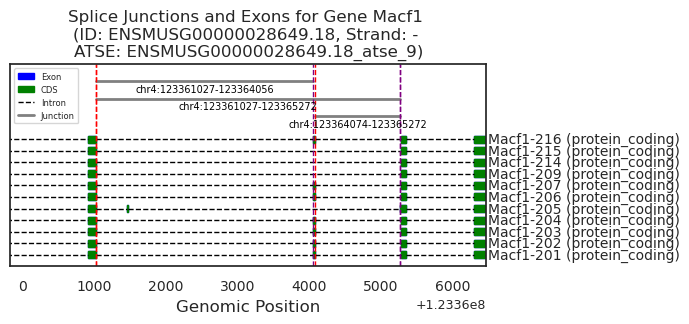

ATSE visualization saved: mouse_ENSMUSG00000028649.18_atse_9.pdf


{'junctions':                            event_id                gene_id gene_name  \
 29933  ENSMUSG00000028649.18_atse_9  ENSMUSG00000028649.18     Macf1   
 29934  ENSMUSG00000028649.18_atse_9  ENSMUSG00000028649.18     Macf1   
 29935  ENSMUSG00000028649.18_atse_9  ENSMUSG00000028649.18     Macf1   
 
            gene_types  num_junctions event_type chromosome strand  atse_start  \
 29933  protein_coding              3    complex       chr4      -   123361027   
 29934  protein_coding              3    complex       chr4      -   123361027   
 29935  protein_coding              3    complex       chr4      -   123361027   
 
         atse_end  ...  donor_total_reads  acceptor_total_reads  splice_motif  \
 29933  123365272  ...             164551                 70767         GT-AG   
 29934  123365272  ...             176645                164551         GT-AG   
 29935  123365272  ...              82861                176645         GT-AG   
 
        donor_seq  acceptor_seq  posi

In [64]:
mouse_event = "ENSMUSG00000028649.18_atse_9"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", base_width=7, 
                       trans_height=0.2, 
                  padding=200, show_junc_lines=True)

In [65]:
# save final_df to csv 
final_df.to_csv(f"{OUTPUT_DIR}/final_df.tsv.gz", index=False, sep="\t", compression="gzip")
print(f"Saved final_df to {OUTPUT_DIR}/final_df.tsv.gz")

Saved final_df to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/final_df.tsv.gz
